In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]   # go from notebooks → Python
SRC_PATH = PROJECT_ROOT / "Python" / "src"

sys.path.append(str(SRC_PATH))

print("Added to path:", SRC_PATH)


repo_root = Path.cwd().parent  # adjust if needed
sys.path.insert(0, str(repo_root))

print("Added to path:", repo_root)

# ============================================
# AIR WHEEL — MP4 DIRECTORY SCANNER
# NeuroMomentum Lab
# ============================================

from pathlib import Path
import json

ROOT = Path("/mnt/pdata_bak/Air_Wheel_Methods")

# --- animals and dates of interest ---
TARGETS = {
    "NML_04": "2026_01_24",
    "NML_05": "2026_01_14",
    "NML_06": "2026_01_16",
}

ROI_REF_ANIMAL = "NML_GC_01"
ROI_REF_DATE   = "2025_12_16"


def pick_video_file(folder: Path, prefix: str, allow_reduced=True):
    """
    Pick appropriate mp4 file based on prefix and reduction rules.
    """

    files = sorted(
        f for f in folder.glob(f"{prefix}*.mp4")
        if "reduced" not in f.name.lower()
    )

    if not files:
        return ""

    # pupil never uses reduced
    if prefix == "pupi":
        return str(files[0])

    # face/video prefer reduced
    if allow_reduced:
        reduced = [f for f in files if "_reduced" in f.name]
        if reduced:
            return str(reduced[0])

    return str(files[0])


def build_airwheel_dict():
    animals = []

    for animal, date in TARGETS.items():

        session_dir = ROOT / animal / date

        if not session_dir.exists():
            print(f"[WARNING] Missing folder: {session_dir}")
            continue

        info = {
            "ID": animal,
            "date": date,
            "session_dir": str(session_dir),
            "video": {
                "mp4": {
                    "face": "",
                    "pupil": "",
                    "paws": "",
                }
            },
            "roi_reference": {
                "animal": ROI_REF_ANIMAL,
                "date": ROI_REF_DATE,
            }
        }

        # ---------- detect videos ----------
        info["video"]["mp4"]["face"]  = pick_video_file(session_dir, "face")
        info["video"]["mp4"]["pupil"] = pick_video_file(session_dir, "pupi")
        info["video"]["mp4"]["paws"]  = pick_video_file(session_dir, "video")

        animals.append(info)

    return animals


# ============================================
# BUILD STRUCTURE
# ============================================

airwheel_data = build_airwheel_dict()

print("\n===== SUMMARY =====")
for a in airwheel_data:
    print(a["ID"], a["date"])
    print("  face :", a["video"]["mp4"]["face"])
    print("  pupil:", a["video"]["mp4"]["pupil"])
    print("  paws :", a["video"]["mp4"]["paws"])


Added to path: /home/nmldata2/ttpaw/Python/src
Added to path: /home/nmldata2/ttpaw/Python

===== SUMMARY =====
NML_04 2026_01_24
  face : /mnt/pdata_bak/Air_Wheel_Methods/NML_04/2026_01_24/face_1440x1080_60_20260124_154254.mp4
  pupil: /mnt/pdata_bak/Air_Wheel_Methods/NML_04/2026_01_24/pupi_320x240_60_20260124_154254.mp4
  paws : /mnt/pdata_bak/Air_Wheel_Methods/NML_04/2026_01_24/video_20260124_154256.mp4
NML_05 2026_01_14
  face : /mnt/pdata_bak/Air_Wheel_Methods/NML_05/2026_01_14/face_1440x1080_60_20260114_164026.mp4
  pupil: /mnt/pdata_bak/Air_Wheel_Methods/NML_05/2026_01_14/pupi_320x240_60_20260114_164026.mp4
  paws : /mnt/pdata_bak/Air_Wheel_Methods/NML_05/2026_01_14/video_20260114_164026.mp4
NML_06 2026_01_16
  face : /mnt/pdata_bak/Air_Wheel_Methods/NML_06/2026_01_16/face_1440x1080_60_20260116_154145.mp4
  pupil: /mnt/pdata_bak/Air_Wheel_Methods/NML_06/2026_01_16/pupi_320x240_60_20260116_154145.mp4
  paws : /mnt/pdata_bak/Air_Wheel_Methods/NML_06/2026_01_16/video_20260116_154140

In [5]:
from src.utils.frame_funcs import extract_first_frames_airwheel

extract_first_frames_airwheel(airwheel_data)

[SAVED] /mnt/pdata_bak/Air_Wheel_Methods/NML_04/2026_01_24/face_1440x1080_60_20260124_154254_firstframe.png
[SAVED] /mnt/pdata_bak/Air_Wheel_Methods/NML_04/2026_01_24/pupi_320x240_60_20260124_154254_firstframe.png
[SAVED] /mnt/pdata_bak/Air_Wheel_Methods/NML_04/2026_01_24/video_20260124_154256_firstframe.png
[SAVED] /mnt/pdata_bak/Air_Wheel_Methods/NML_05/2026_01_14/face_1440x1080_60_20260114_164026_firstframe.png
[SAVED] /mnt/pdata_bak/Air_Wheel_Methods/NML_05/2026_01_14/pupi_320x240_60_20260114_164026_firstframe.png
[SAVED] /mnt/pdata_bak/Air_Wheel_Methods/NML_05/2026_01_14/video_20260114_164026_firstframe.png
[SAVED] /mnt/pdata_bak/Air_Wheel_Methods/NML_06/2026_01_16/face_1440x1080_60_20260116_154145_firstframe.png
[SAVED] /mnt/pdata_bak/Air_Wheel_Methods/NML_06/2026_01_16/pupi_320x240_60_20260116_154145_firstframe.png
[SAVED] /mnt/pdata_bak/Air_Wheel_Methods/NML_06/2026_01_16/video_20260116_154140_firstframe.png


In [2]:
print(airwheel_data)

[{'ID': 'NML_04', 'date': '2026_01_24', 'session_dir': '/mnt/pdata_bak/Air_Wheel_Methods/NML_04/2026_01_24', 'video': {'mp4': {'face': '/mnt/pdata_bak/Air_Wheel_Methods/NML_04/2026_01_24/face_1440x1080_60_20260124_154254.mp4', 'pupil': '/mnt/pdata_bak/Air_Wheel_Methods/NML_04/2026_01_24/pupi_320x240_60_20260124_154254.mp4', 'paws': '/mnt/pdata_bak/Air_Wheel_Methods/NML_04/2026_01_24/video_20260124_154256.mp4'}}, 'roi_reference': {'animal': 'NML_GC_01', 'date': '2025_12_16'}}, {'ID': 'NML_05', 'date': '2026_01_14', 'session_dir': '/mnt/pdata_bak/Air_Wheel_Methods/NML_05/2026_01_14', 'video': {'mp4': {'face': '/mnt/pdata_bak/Air_Wheel_Methods/NML_05/2026_01_14/face_1440x1080_60_20260114_164026.mp4', 'pupil': '/mnt/pdata_bak/Air_Wheel_Methods/NML_05/2026_01_14/pupi_320x240_60_20260114_164026.mp4', 'paws': '/mnt/pdata_bak/Air_Wheel_Methods/NML_05/2026_01_14/video_20260114_164026.mp4'}}, 'roi_reference': {'animal': 'NML_GC_01', 'date': '2025_12_16'}}, {'ID': 'NML_06', 'date': '2026_01_16', 


Processing NML_04 | 2026_01_24
[INFO] Opening video: /mnt/pdata_bak/Air_Wheel_Methods/NML_04/2026_01_24/face_1440x1080_60_20260124_154254.mp4

Draw LED ROI → press ENTER when done


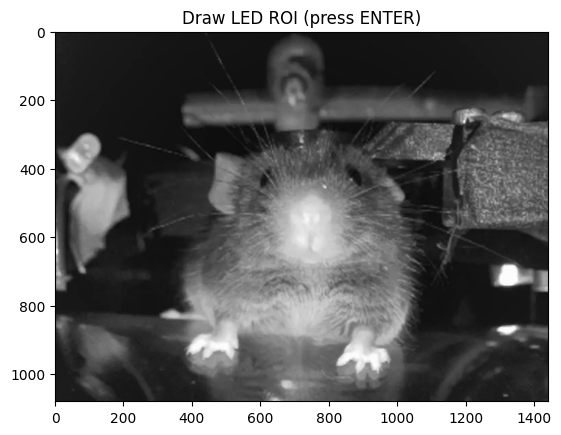

RuntimeError: LED ROI not selected

In [3]:
from src.utils.extract_led_signal import run_led_roi_selection

run_led_roi_selection(airwheel_data)

In [4]:
import cv2
import numpy as np

img = np.zeros((400,400,3), dtype=np.uint8)
cv2.imshow("test", img)
cv2.waitKey(0)
cv2.destroyAllWindows()

error: OpenCV(4.14.0-pre) /home/nmldata2/opencv/modules/highgui/src/window_gtk.cpp:638: error: (-2:Unspecified error) Can't initialize GTK backend in function 'cvInitSystem'
